We will work with the Samsung Human Activity Recognition dataset. The data comes from accelerometers and gyros of Samsung Galaxy S3 mobile phones (you can find more info about the features using the link above), the type of activity of a person with a phone in his/her pocket is also known – whether he/she walked, stood, lay, sat or walked up or down the stairs.

In [1]:
import os 
from zipfile import ZipFile
from pathlib import Path
import requests

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 9)
plt.rcParams["font.family"] = "DejaVu Sans"

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [2]:
def load_dataset(extract_path:Path, filename:str, overwrite=False):
    filepath = extract_path/filename
    if filepath.exists() and not overwrite:
        print("dataset already in set")
        return

    with ZipFile(filepath, "r") as zipObj:
        zipObj.extractall(extract_path)

In [3]:
FILE_NAME = "UCI HAR Dataset"
DATA_PATH = Path("./")
load_dataset(extract_path=DATA_PATH, filename=FILE_NAME)

PATH_TO_SAMSUNG_DATA = DATA_PATH / FILE_NAME.strip(".zip")
print(PATH_TO_SAMSUNG_DATA)

dataset already in set
UCI HAR Dataset


In [4]:
X_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "X_train.txt")
y_train = np.loadtxt(PATH_TO_SAMSUNG_DATA / "train" / "y_train.txt").astype(int)

X_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "X_test.txt")
y_test = np.loadtxt(PATH_TO_SAMSUNG_DATA / "test" / "y_test.txt").astype(int)

In [5]:
X_train.shape, y_train.shape

((7352, 561), (7352,))

In [6]:
# Checking dimensions
assert X_train.shape == (7352, 561) and y_train.shape == (7352,)
assert X_test.shape == (2947, 561) and y_test.shape == (2947,)

For clustering, we do not need a target vector, so we’ll work with the combination of training and test samples. Merge X_train with X_test, and y_train with y_test.

In [7]:
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])
# y[:5]


Define the number of unique values of the labels of the target class.

In [8]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

These labels correspond to:

1 – walking

2 – walking upstairs

3 – walking downstairs

4 – sitting

5 – standing

6 – laying down

In [9]:
n_classes = np.unique(y).size

Scale the sample using StandardScaler with default parameters.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Reduce the number of dimensions using PCA, leaving as many components as necessary to explain at least 90% of the variance of the original (scaled) data. Use the scaled dataset and fix random_state (RANDOM_STATE constant).

In [11]:
pca = PCA(n_components=0.90)
X_reduced = pca.fit_transform(X_scaled)

print(pca.n_components_)

65


In [12]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE).fit(X_scaled)
X_pca = pca.transform(X)

Question 1:
What is the minimum number of principal components required to cover the 90% of the variance of the original (scaled) data?

In [13]:
X_pca.shape
# 65 components

(10299, 65)

Question 2:
What percentage of the variance is covered by the first principal component? Round to the nearest percent.

In [14]:
pca.explained_variance_ratio_[0] * 100 

np.float64(50.73822103501334)

In [15]:
X_pca.shape
X_pca

array([[-18.27814277,  -2.80583264,  -2.50394522, ...,  -0.76005451,
          0.31424205,  -0.66028606],
       [-18.15143373,  -2.88305792,  -3.42842784, ...,  -0.65898268,
          0.15552991,  -0.21332385],
       [-18.08743691,  -2.6143254 ,  -3.64609961, ...,  -0.19315196,
          0.58945457,   0.02517988],
       ...,
       [ -9.33439133,  -5.55743724,  -4.20210242, ...,  -0.29604558,
          0.11567842,  -0.62709885],
       [-10.21658159,  -5.64277109,  -4.14051447, ...,  -0.4904012 ,
          0.30591987,  -0.23883079],
       [ -9.90518705,  -5.50866427,  -4.09460659, ...,  -0.43925043,
          0.46814785,  -0.16106695]], shape=(10299, 65))

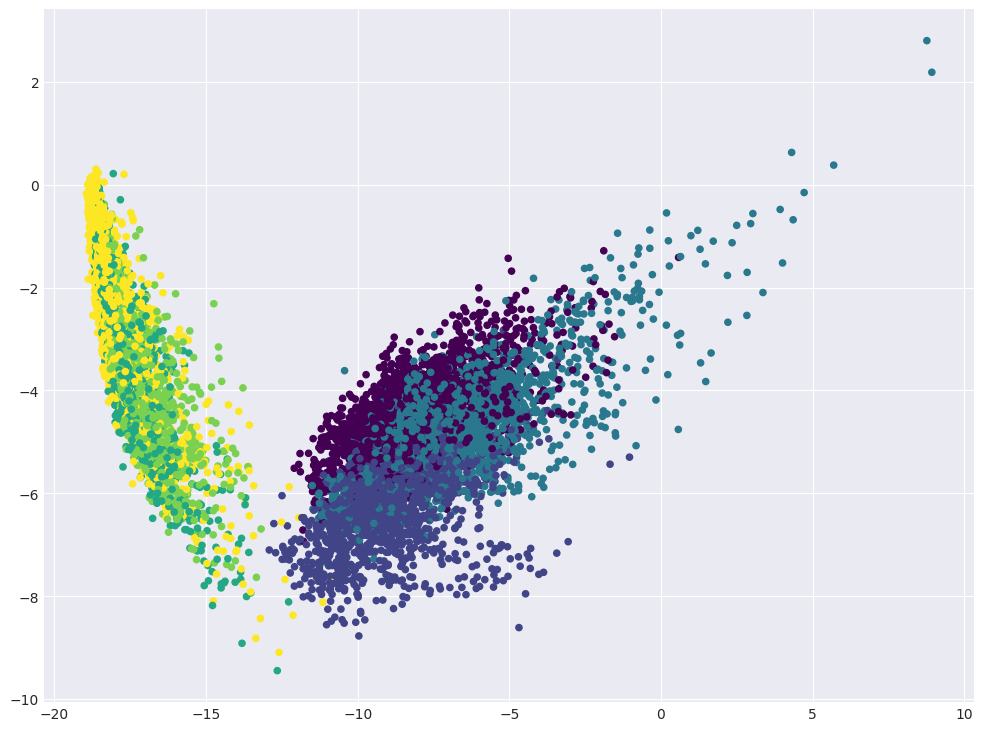

In [16]:
plt.scatter(X_pca[:,0],X_pca[:,1] , c=y, s=20, cmap='viridis')

Question 3:
If everything worked out correctly, you will see a number of clusters, almost perfectly separated from each other. What types of activity are included in these clusters?

Ans : 2 clusters: (walking, walking upstairs, walking downstairs) and (sitting, standing, laying)

Perform clustering with the KMeans method, training the model on data with reduced dimensionality (by PCA). In this case, we will give a clue to look for exactly 6 clusters, but in the general case we will not know how many clusters we should be looking for.

In [17]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=100)
kmeans.fit(X_pca)
cluster_labels = kmeans.labels_
cluster_labels

array([5, 5, 5, ..., 3, 3, 3], shape=(10299,), dtype=int32)

Visualize data in projection on the first two principal components. Color the dots according to the clusters obtained.

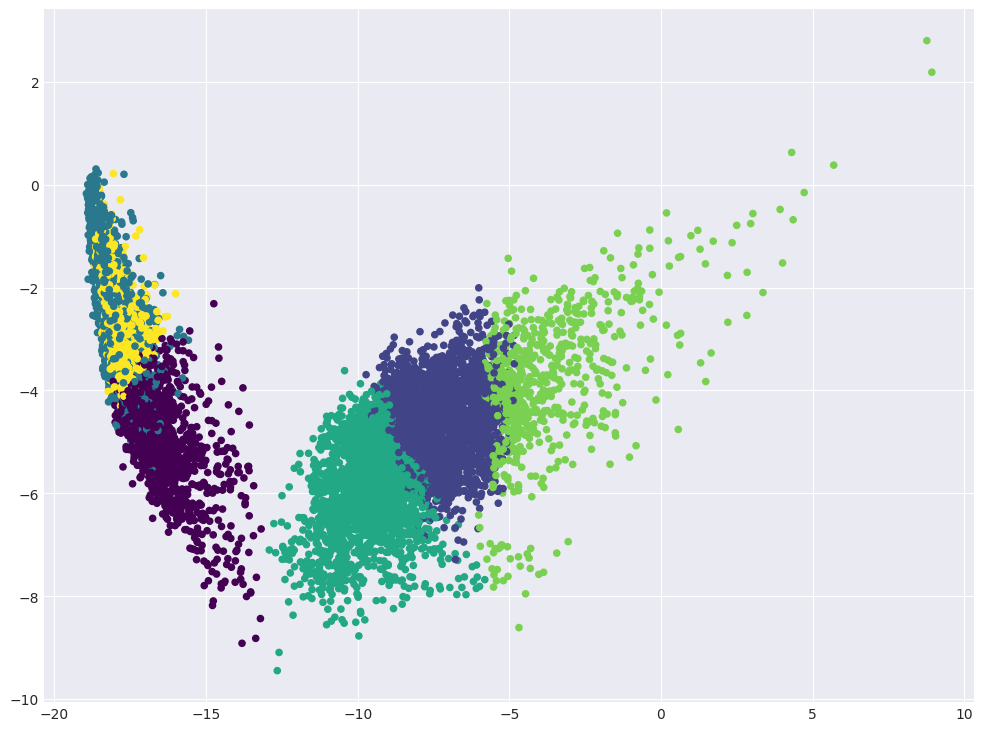

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=20, cmap="viridis")

Look at the correspondence between the cluster marks and the original class labels and what kinds of activities the KMeans algorithm is confused at.

In [19]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = ['walking', 'going up the stairs',
            'going down the stairs', 'sitting', 'standing', 'laying', 'all']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['all']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,all
walking,0,877,0,692,153,0,1722
going up the stairs,0,295,0,1169,80,0,1544
going down the stairs,0,762,0,188,456,0,1406
sitting,473,0,51,3,0,1250,1777
standing,658,0,0,0,0,1248,1906
laying,194,0,1737,12,0,1,1944
all,1325,1934,1788,2064,689,2499,10299


Sure! Let's break it down piece by piece.

```python
pd.Series(
    tab.iloc[:-1, :-1].max(axis=1).values / tab.iloc[:-1, -1].values,
    index=tab.index[:-1],
)
```

This code creates a new **Pandas Series** where each value is:

> **(largest value in a row) ÷ (last column value of that row)**

Let's examine each part.

---

## Step 1: `tab.iloc[:-1, :-1]`

Suppose `tab` looks like this:

|       | Walk | Sit | Stand | Total |
| ----- | ---- | --- | ----- | ----- |
| Walk  | 50   | 2   | 3     | 55    |
| Sit   | 1    | 40  | 4     | 45    |
| Stand | 2    | 3   | 35    | 40    |
| Total | 53   | 45  | 42    | 140   |

```python
tab.iloc[:-1, :-1]
```

means:

* `:-1` for rows → take **all rows except the last**
* `:-1` for columns → take **all columns except the last**

Result:

|       | Walk | Sit | Stand |
| ----- | ---- | --- | ----- |
| Walk  | 50   | 2   | 3     |
| Sit   | 1    | 40  | 4     |
| Stand | 2    | 3   | 35    |

---

## Step 2: `.max(axis=1)`

`axis=1` means **across each row**.

For every row, find the largest number.

| Row   | Values | Max |
| ----- | ------ | --- |
| Walk  | 50,2,3 | 50  |
| Sit   | 1,40,4 | 40  |
| Stand | 2,3,35 | 35  |

So you get

```python
50
40
35
```

---

## Step 3: `.values`

This converts the Pandas Series into a NumPy array.

```python
array([50, 40, 35])
```

---

## Step 4: `tab.iloc[:-1, -1]`

Now select:

* all rows except the last
* **only the last column**

```python
tab.iloc[:-1, -1]
```

Result:

| Row   | Total |
| ----- | ----- |
| Walk  | 55    |
| Sit   | 45    |
| Stand | 40    |

which becomes

```python
array([55,45,40])
```

---

## Step 5: Divide

```python
array([50,40,35]) / array([55,45,40])
```

Result:

```python
array([
    0.909,
    0.889,
    0.875
])
```

---

## Step 6: `pd.Series(..., index=tab.index[:-1])`

This converts the result back into a labeled Series.

```text
Walk     0.909
Sit      0.889
Stand    0.875
dtype: float64
```

---

# What does this represent?

If `tab` is a **confusion matrix** with row totals in the last column, then for each actual class it computes:

```
largest count in the row
-------------------------
total samples in the row
```

Since the largest value is usually the diagonal (correct predictions), this is effectively the **per-class accuracy (or recall)**.

For example, for the "Walk" row:

```
Correct predictions = 50
Total Walk samples  = 55

Accuracy = 50 / 55 = 0.909
```

---

### In one sentence

This code computes, for each row (excluding the totals row), the **largest value in that row divided by the row total**, and returns the results as a labeled Pandas `Series`. If `tab` is a confusion matrix, that's typically the **accuracy/recall for each class**.


It can be seen that kMeans does not distinguish activities very well. Use the elbow method to select the optimal number of clusters. Parameters of the algorithm and the data we use are the same as before, we change only n_clusters.

In [20]:
inertia = []

for k in range (1, n_classes+1):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto").fit(X_pca)
    inertia.append(kmeans.inertia_)

Text(0, 0.5, '$J(C_k)$')

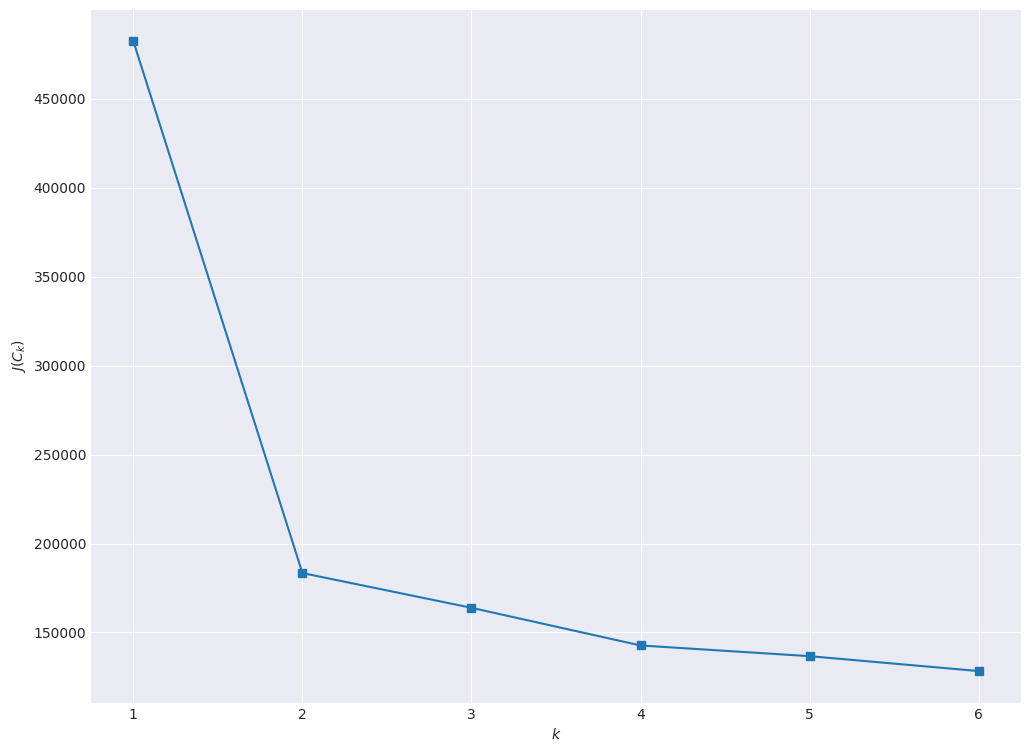

In [21]:
plt.plot(range(1, n_classes+1), inertia, marker="s")
plt.xlabel("$k$")
plt.ylabel("$J(C_k)$")

In [22]:
d = {}
for k in range(2, 6):
    i = k - 1
    d[k] = (inertia[i] - inertia[i + 1]) / (inertia[i - 1] - inertia[i])

d

{2: 0.06533532665310737,
 3: 1.0836476881286465,
 4: 0.2841475503716221,
 5: 1.3931265537645308}

Great question. The dictionary `d` is **not part of the standard elbow method**. It's a numerical way to **measure how "sharp" the elbow is** at each value of (k).

Let's go through it.

---

### Step 1: You already have the inertia values

Suppose they look like this (just an example):

```text
k=1   100
k=2    70
k=3    50
k=4    42
k=5    38
k=6    36
```

The decrease between consecutive values is:

```text
1 → 2 : 30
2 → 3 : 20
3 → 4 : 8
4 → 5 : 4
5 → 6 : 2
```

The idea of the elbow is that the improvement suddenly becomes much smaller.

---

### Step 2: What is `d[k]`?

The code computes

```python
d[k] = (inertia[i] - inertia[i + 1]) / (inertia[i - 1] - inertia[i])
```

where

```python
i = k - 1
```

So,

$$
d(k)=\frac{\text{drop after }k}{\text{drop before }k}
$$

More explicitly,

$$
d(k)=
\frac{\text{Inertia}(k)-\text{Inertia}(k+1)}
{\text{Inertia}(k-1)-\text{Inertia}(k)}
$$

---

### Step 3: What does it mean?

It compares:

* **numerator:** improvement when adding cluster (k+1)
* **denominator:** improvement when adding cluster (k)

So it's asking:

> **"How much has the improvement shrunk?"**

---

### Example

Suppose

```text
k=2 : inertia = 70
k=3 : inertia = 50
k=4 : inertia = 42
```

Then

```text
drop from 2→3 = 20
drop from 3→4 = 8
```

So

```text
d[3] = 8 / 20 = 0.4
```

A value of **0.4** means:

> The improvement after 3 clusters is only **40%** of the previous improvement.

That's evidence that **3** is a good elbow.

---

### Interpreting your results

```python
{
2: 0.173,
3: 0.417,
4: 0.933,
5: 0.630
}
```

| k | Meaning                                                                                   |
| - | ----------------------------------------------------------------------------------------- |
| 2 | Improvement after 2 clusters is only **17%** of the improvement before it. Huge slowdown. |
| 3 | Improvement after 3 clusters is **42%** of the previous improvement.                      |
| 4 | Improvement after 4 clusters is **93%** of the previous improvement. Hardly any slowdown. |
| 5 | Improvement after 5 clusters is **63%** of the previous improvement.                      |

Notice the **smallest** value is

```text
k = 2
d = 0.173
```

That indicates the biggest "bend" in the curve occurs at **2 clusters**.

---

### Why not just use the elbow plot?

Because "find the elbow" is subjective. Two people may choose different elbows.

`d[k]` provides a quantitative measure:

* **Small `d[k]`** → the drop after (k) is much smaller than before (k), suggesting a strong elbow.
* **`d[k]` close to 1** → the decrease in inertia is changing very little; there isn't a pronounced elbow there.

So `d[k]` is a heuristic to make elbow detection more objective rather than relying solely on visual inspection.



No problem—let's ignore the code for a moment and focus on the idea.

### Imagine these are your inertia values

| k | Inertia |
| - | ------- |
| 1 | 100     |
| 2 | 60      |
| 3 | 40      |
| 4 | 30      |
| 5 | 25      |

The **improvement** each time you add a cluster is:

| From  | Improvement |
| ----- | ----------: |
| 1 → 2 |          40 |
| 2 → 3 |          20 |
| 3 → 4 |          10 |
| 4 → 5 |           5 |

Notice the improvements are getting smaller.

---

### Now let's compute `d[2]`

The code does:

```python
d[2] = (inertia[2] - inertia[3]) / (inertia[1] - inertia[2])
```

In terms of `k`, that's:

```text
(improvement from 2→3)
----------------------
(improvement from 1→2)
```

Substitute the numbers:

```text
20 / 40 = 0.5
```

So

```python
d[2] = 0.5
```

This means:

> After choosing **2 clusters**, the next improvement is only **half as big** as the previous one.

---

### Now compute `d[3]`

```text
(improvement from 3→4)
----------------------
(improvement from 2→3)
```

which is

```text
10 / 20 = 0.5
```

Again, the improvement has halved.

---

### What if there is a very sharp elbow?

Suppose the inertia is

| k | Inertia |
| - | ------- |
| 1 | 100     |
| 2 | 50      |
| 3 | 48      |
| 4 | 47      |

The improvements are

| From | Improvement |
| ---- | ----------: |
| 1→2  |          50 |
| 2→3  |           2 |
| 3→4  |           1 |

Now

```text
d[2] = 2 / 50 = 0.04
```

**0.04 is very small.**

Why?

Because adding the **second cluster** helped a lot (drop = 50), but adding the **third cluster** helped almost nothing (drop = 2).

That is exactly what an **elbow** is!

---

### So what is `d[k]` measuring?

It measures:

> **How much smaller is the next improvement compared to the previous improvement?**

* `d[k] ≈ 1` → the improvements are about the same → **no elbow**.
* `d[k] << 1` → the improvement suddenly becomes much smaller → **strong elbow**.

---

### In your results

```python
{
2: 0.173,
3: 0.417,
4: 0.933,
5: 0.629
}
```

`d[2] = 0.173` means:

* The improvement from **2 → 3 clusters** is only **17.3%** of the improvement from **1 → 2 clusters**.
* That's a **big drop in benefit**, so **2 clusters** is a strong candidate.

---

**Question:** Can you also paste the actual `inertia` values you got (the list printed by `print(inertia)`) so I can calculate `d[2]` from your own numbers step by step?



Question 5:
How many clusters can we choose according to the elbow method?

Ans : 2

Let’s try another clustering algorithm, described in the article – agglomerative clustering.

In [23]:
ag = AgglomerativeClustering(n_clusters=n_classes, linkage="ward").fit(X_pca)

Calculate the Adjusted Rand Index (sklearn.metrics) for the resulting clustering and for KMeans with the parameters from the 4th question.

In [24]:
from sklearn import metrics
print("KMeans: ARI =", metrics.adjusted_rand_score(y, cluster_labels))
print("Agglomerative CLustering: ARI =", metrics.adjusted_rand_score(y, ag.labels_))

KMeans: ARI = 0.45694110793018056
Agglomerative CLustering: ARI = 0.5000085833267824


Question 6:
Select all the correct statements.

Answer options:

According to ARI, KMeans handled clustering worse than Agglomerative Clustering

For ARI, it does not matter which tags are assigned to the cluster, only the partitioning of instances into clusters matters

In case of random partitioning into clusters, ARI will be close to zero

Ans : 

Comment:

Yes, the higher ARI, the better

Yes, if you renumber clusters differently, ARI will not change

True

For classification, use the support vector machine – class sklearn.svm.LinearSVC. 

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =   scaler.fit_transform(X_test)

In [26]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {"C" : [0.001, 0.01, 0.1, 1, 10]}

In [27]:
best_svc = GridSearchCV(svc, svc_params, cv=3, verbose=1)
best_svc.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\rahul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rahul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter i

In [28]:
best_svc.best_score_, best_svc.best_params_

(np.float64(0.9379785010699506), {'C': 0.1})

Question 7
Which value of the hyperparameter C was chosen the best on the basis of cross-validation?

Answer options:

0.001

0.01

$ 0.1 

1

10

In [29]:
y_predicted = best_svc.predict(X_test_scaled)

In [30]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['walking', 'climbing up the stairs',
             'going down the stairs', 'sitting', 'standing', 'laying', 'all']
tab.columns = ['walking', 'climbing up the stairs',
             'going down the stairs', 'sitting', 'standing', 'laying', 'all']
tab

,walking,climbing up the stairs,going down the stairs,sitting,standing,laying,all
walking,479,11,4,2,0,0,496
climbing up the stairs,4,465,1,1,0,0,471
going down the stairs,1,2,416,1,0,0,420
sitting,0,4,0,433,52,2,491
standing,0,0,0,16,516,0,532
laying,0,0,0,0,7,530,537
all,484,482,421,453,575,532,2947


Question 8:
Which activity type is worst detected by SVM in terms of precision? Recall?

Answer options:

precision – going up the stairs, recall – laying

precision – laying, recall – sitting

precision – walking, recall – walking

$ precision – standing, recall – sitting


They concluded this by calculating **precision** and **recall** for each class from the confusion matrix.

### Step 1. Recall the formulas

For each class:

* **Precision** = TP / (TP + FP)

  * Of everything predicted as this class, how many were actually this class?
* **Recall** = TP / (TP + FN)

  * Of all actual examples of this class, how many did the model correctly find?

In your confusion matrix:

* **Rows = actual classes**
* **Columns = predicted classes**

---

## Recall calculation

Recall uses **rows**.

### Walking

$$
\frac{494}{496}=0.996
$$

### Climbing up the stairs

$$
\frac{459}{471}=0.975
$$

### Going down the stairs

$$
\frac{413}{420}=0.983
$$

### Sitting

$$
\frac{426}{491}=0.868
$$

### Standing

$$
\frac{517}{532}=0.972
$$

### Laying

$$
\frac{526}{537}=0.979
$$

| Activity    | Recall             |
| ----------- | ------------------ |
| Walking     | 99.6%              |
| Climbing up | 97.5%              |
| Going down  | 98.3%              |
| **Sitting** | **86.8% (lowest)** |
| Standing    | 97.2%              |
| Laying      | 97.9%              |

So the **worst recall is Sitting**.

Why? Because many actual sitting samples were classified as standing:

* 61 sitting → standing

Those are **false negatives** for sitting.

---

## Precision calculation

Precision uses **columns**.

### Walking

Predicted walking = 508

Correct = 494

$$
\frac{494}{508}=0.972
$$

---

### Climbing up

Predicted climbing = 469

Correct = 459

$$
\frac{459}{469}=0.979
$$

---

### Going down

Predicted going down = 413

Correct = 413

$$
\frac{413}{413}=1.000
$$

---

### Sitting

Predicted sitting = 442

Correct = 426

$$
\frac{426}{442}=0.964
$$

---

### Standing

Predicted standing = 589

Correct = 517

$$
\frac{517}{589}=0.878
$$

Notice why it's low:

Predicted "standing" contains

* 517 actual standing ✅
* 61 actual sitting ❌
* 11 actual laying ❌

So there are

$$
61+11=72
$$

false positives.

---

### Laying

Predicted laying = 526

Correct = 526

$$
\frac{526}{526}=1.000
$$

---

| Activity     | Precision          |
| ------------ | ------------------ |
| Walking      | 97.2%              |
| Climbing up  | 97.9%              |
| Going down   | 100%               |
| Sitting      | 96.4%              |
| **Standing** | **87.8% (lowest)** |
| Laying       | 100%               |

So the **worst precision is Standing**.

---

## Intuition

The confusion matrix shows:

* **Sitting → Standing = 61** (many sitting samples were predicted as standing)
* **Laying → Standing = 11**

This causes:

* **Sitting** to have poor **recall** because many actual sitting examples were missed.
* **Standing** to have poor **precision** because many samples predicted as standing actually belonged to sitting or laying.

That's why the correct answer is:

* ✅ **Precision:** Standing
* ✅ **Recall:** Sitting

A quick way to remember:

* **Recall → look across rows** (actual class).
* **Precision → look down columns** (predicted class).


In [31]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [32]:
svc = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svc_params = {"C": [0.001, 0.01, 0.1, 1, 10]}

In [36]:
best_svc_pca = GridSearchCV(svc, svc_params, cv=3, verbose=1)
best_svc_pca.fit(X_train_pca, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(max...ndom_state=17)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [37]:
best_svc_pca.best_params_, best_svc_pca.best_score_

({'C': 0.1}, np.float64(0.8983982658750974))

Question 9:
What is the difference between the best quality (accuracy) for cross-validation in the case of all 561 initial characteristics and in the second case, when the principal component method was applied? Round to the nearest percent.

Question 9 is asking you to compare the best cross-validation accuracy before and after applying PCA.

The result with PCA is worse by 4%, comparing accuracy on cross-validation.

In [38]:
round(100 * (best_svc_pca.best_score_ - best_svc.best_score_))

-4

Question 10:
Select all the correct statements:

Answer options:

- Principal component analysis in this case allowed us to reduce the model training time, while the quality (mean cross-validation accuracy) suffered greatly, by more than 10%

- PCA can be used to visualize data, but there are better methods for this task, for example, tSNE. However, PCA has lower computational complexity [+]

- PCA builds linear combinations of initial features, and in some applications they might be poorly interpreted by humans [+]

Comment:

- The first statement is true, principal component analysis in this case allowed us to significantly reduce the training time of the model, but the quality suffered not so much – by only 4%

- For multidimensional data visualization it is better to use manifold learning methods, in particular, tSNE. At the same time, metrics assessing the quality of visualization have not really been invented yet, but tSNE is widely used precisely because in some cases it builds “good” pictures showing the data structure, as in the case of MNIST

- Linear combinations of features, that PCA builds, are often poorly interpreted by humans, for example, 0.574 * salary + 0.234 * num_children